<a href="https://colab.research.google.com/github/sasaitals/Data-Science-testando-rela-es-com-Regress-o-Linear/blob/main/Aula3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [5]:
#Lendo os dados
dados = pd.read_csv("/content/Preços_de_casas.csv")

In [6]:
#Fatores coletados
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Id                              1438 non-null   int64  
 1   area_primeiro_andar             1438 non-null   float64
 2   existe_segundo_andar            1438 non-null   int64  
 3   area_segundo_andar              1438 non-null   float64
 4   quantidade_banheiros            1438 non-null   int64  
 5   capacidade_carros_garagem       1438 non-null   int64  
 6   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 7   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(5)
memory usage: 90.0 KB


In [7]:
dados = dados.drop(columns = "Id")
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1438 entries, 0 to 1437
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   area_primeiro_andar             1438 non-null   float64
 1   existe_segundo_andar            1438 non-null   int64  
 2   area_segundo_andar              1438 non-null   float64
 3   quantidade_banheiros            1438 non-null   int64  
 4   capacidade_carros_garagem       1438 non-null   int64  
 5   qualidade_da_cozinha_Excelente  1438 non-null   int64  
 6   preco_de_venda                  1438 non-null   float64
dtypes: float64(3), int64(4)
memory usage: 78.8 KB


#Correlação

In [8]:
corr = dados.corr()

In [9]:
#Entendemos que a maior relação do preço da casa, tem a ver com a area do primeiro andar
corr['preco_de_venda']

,preco_de_venda
area_primeiro_andar,0.616557
existe_segundo_andar,0.138541
area_segundo_andar,0.305311
quantidade_banheiros,0.563132
capacidade_carros_garagem,0.640214
qualidade_da_cozinha_Excelente,0.496223
preco_de_venda,1.000000


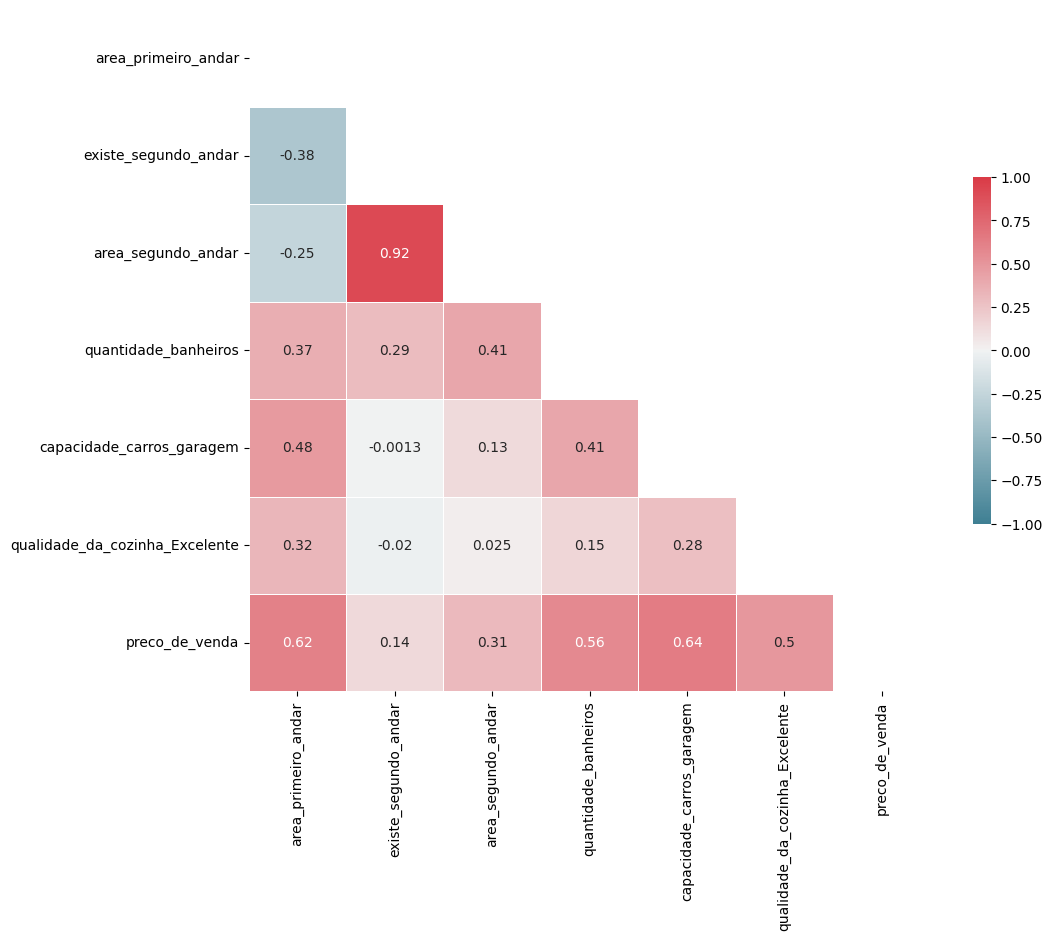

In [10]:
# Gerar uma máscara para o triângulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar a figura do matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Gerar o mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

# Exibir o mapa de calor (heatmap)
plt.show()
#Gráfico de dispersao

Text(0, 0.5, 'Preço de Venda')

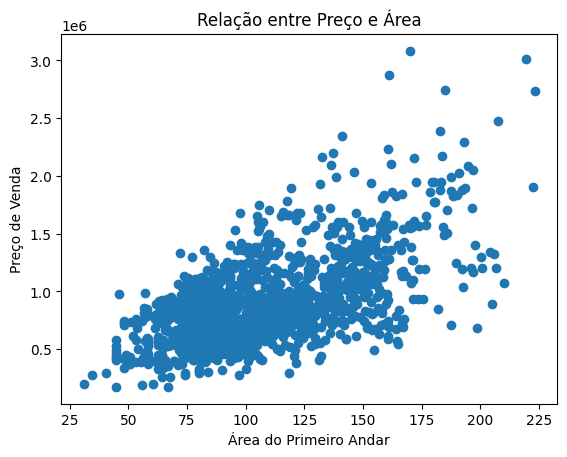

In [11]:
#Como é a relação entre área contruida e preço do imóvel

plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'])
plt.title("Relação entre Preço e Área")
plt.xlabel("Área do Primeiro Andar")
plt.ylabel("Preço de Venda")

Text(0, 0.5, 'Preço de Venda')

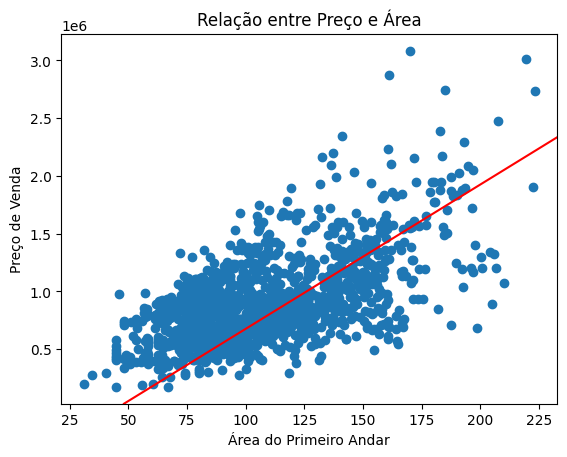

In [12]:
#Quanto maior a área do primeiro andar, maior o preço da casa
#Traçar uma linha pata melhor representar:
plt.scatter(dados['area_primeiro_andar'], dados['preco_de_venda'])
plt.axline(xy1 = (66, 250000),xy2 = (190, 1800000), color = "red")

plt.title("Relação entre Preço e Área")
plt.xlabel("Área do Primeiro Andar")
plt.ylabel("Preço de Venda")

#Exemplificando de forma linear a relação de preço e a area, mas essa linha foi feita de forma manual, nos que colocamos os dados, a maquina não os analisou para traçar a linha

#Melor reta

In [13]:
px.scatter(dados, x = 'area_primeiro_andar', y = 'preco_de_venda', trendline_color_override="red", trendline='ols')

#Ajuste da reta
Fórmula **Yᵢ = B₀ + B₁ * Xᵢ**

Seria como dizer **Preço de Venda = (Valor Base do Imóvel) + (Impacto da Área no Preço) * (Área do Primeiro Andar)**

Esta linha nos ajuda a visualizar como a `area_primeiro_andar` explica o
`preco_de_venda`

#Variaveis respostas e explicativas
A variavel resposta é aquela que queremos prever ou explicar, no caso é o `preco_de_venda` e a variavel explicativa é aquela que iremos utilixar para chegar na variavel resposta, no caso, `area_primeiro_andar`

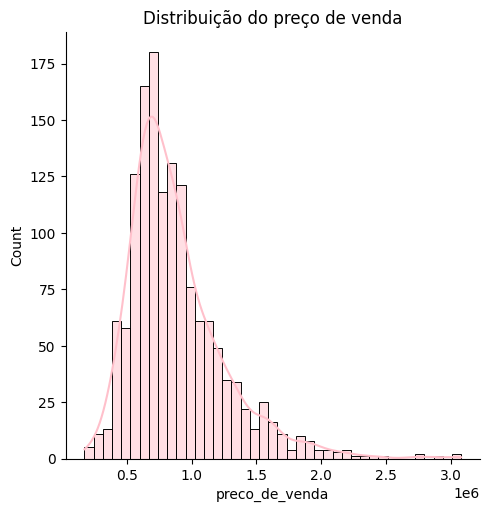

In [14]:
sns.displot(dados['preco_de_venda'], kde=True, color='pink')
plt.title('Distribuição do preço de venda')
plt.show()

#Treino e teste

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
#x os dados que serão analisados para adquirir o y

y = dados['preco_de_venda'] #y é o dado que queremos alcançar
x = dados.drop(columns = 'preco_de_venda') #traduz para "a tabela inteira menos a coluna preco_de_venda". Estes dados serão analisados para adquirir a resposta = ao y

In [17]:
x_train, x_teste, y_train, y_teste = train_test_split(x, y, test_size = 0.3, random_state= 230)
#O random_state serve para que toda vez que o train_test_split coloque o mesmo conjunto de dados no teste e no treino para assim, toda vez que o sistema for executado, tera sempre os msmos dados em treino e teste

In [18]:
#x_trains são organizados em df_train. Não precisa passar os dados pelo Dataframe toda vez, vamos utilizar ele pois o ols espera que os dados fornecidos sejam em DataFrame
df_train = pd.DataFrame(data= x_train) #Colocando todos os dados de treino no DataFrame
#colocando as "respostas" no DataFrame
df_train['preco_de_venda'] = y_train #Adicionando uma coluna com o nome 'preco_de_venda' com os dados de "resposta treino"
#Acima colocamos TODAS as variaveis que serão utilizadas (x-pergunta e y-resposta) em um unico DataFrame para que o ols coniga receber todos

In [19]:
from statsmodels.formula.api import ols

In [20]:
modelo_0 = ols('preco_de_venda ~ area_primeiro_andar', data = df_train).fit() #.fit() SEMPRE ira trinar o modelo
#A parte "'preco_de_venda ~ area_primeiro_andar'" equivale a dizer "Queremos modelar o preco_de_venda em função da area_primeiro_andar"

#Analisando os coeficientes

In [21]:
modelo_0.params
#Interceptor: Caso a area do primeiro andar for 0, o preço da casa iniciará com base de R$152.909,28, ou seja, os valores irão sempre iniciar ou ser acima deste preço
#Efeito Individual: é o valor 6793.64, ou sejá, espera-se que a cada metro quadrado adicionado, o valor da casa aumente em média R$6.793,64

,0
Intercept,152909.288334
area_primeiro_andar,6793.641641


In [22]:
print(modelo_0.summary())
#Quando o P>|t| está muito baixo, significa que ele tem um valor significativo no valor da casa
#As duas linhas acima foi para identificar o quanto de realção a area_primeiro_andar tem com o valor da casa

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.377
Model:                            OLS   Adj. R-squared:                  0.377
Method:                 Least Squares   F-statistic:                     608.3
Date:                Mon, 07 Sep 2026   Prob (F-statistic):          2.22e-105
Time:                        17:51:01   Log-Likelihood:                -14082.
No. Observations:                1006   AIC:                         2.817e+04
Df Residuals:                    1004   BIC:                         2.818e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept            1.529e+05   3

In [23]:
modelo_0.rsquared *100
#pode-se explicar que 37.72% da diferença dos preços da casa é por causa da area do primeiro andar
#quanto mais perto de 1 (100%) melhor é
#Resume-se para: a área do primeiro andar não é determinante para o valor da casa

np.float64(37.72801099429787)

In [24]:
modelo_0.resid

,0
1303,-193023.838744
326,-144522.356193
386,399612.747641
615,-68449.596607
236,166010.592859
...,...
777,465872.680999
271,-497642.319788
723,461150.204718
560,-540482.733402


<function matplotlib.pyplot.show(close=None, block=None)>

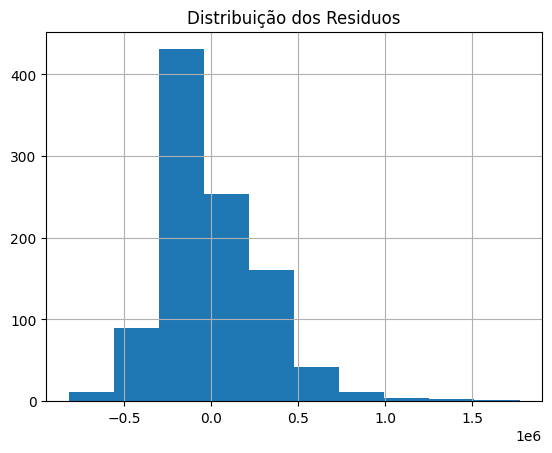

In [25]:
modelo_0.resid.hist()
plt.title("Distribuição dos Residuos")
plt.show
#Espera-se que os residuos estejam bem proximos de 0, pois resulta em  boas métricas de avaliação, mostrando que o modelo é preciso e assertivo.

In [26]:
#após treinar e ajustar o modelo, vamos avaliar sua capacidade de prever com precisão
y_predict = modelo_0.predict(x_teste)

In [27]:
from sklearn.metrics import r2_score

In [28]:
print("R²: ", r2_score(y_teste, y_predict))
#O valor abaixo está muito parecido com os valores reais de 38%,
#porém, apenas 38% dos valores das casas são explicados pela area do primeiro andar

R²:  0.38530928723202407


#Adicionando outras características

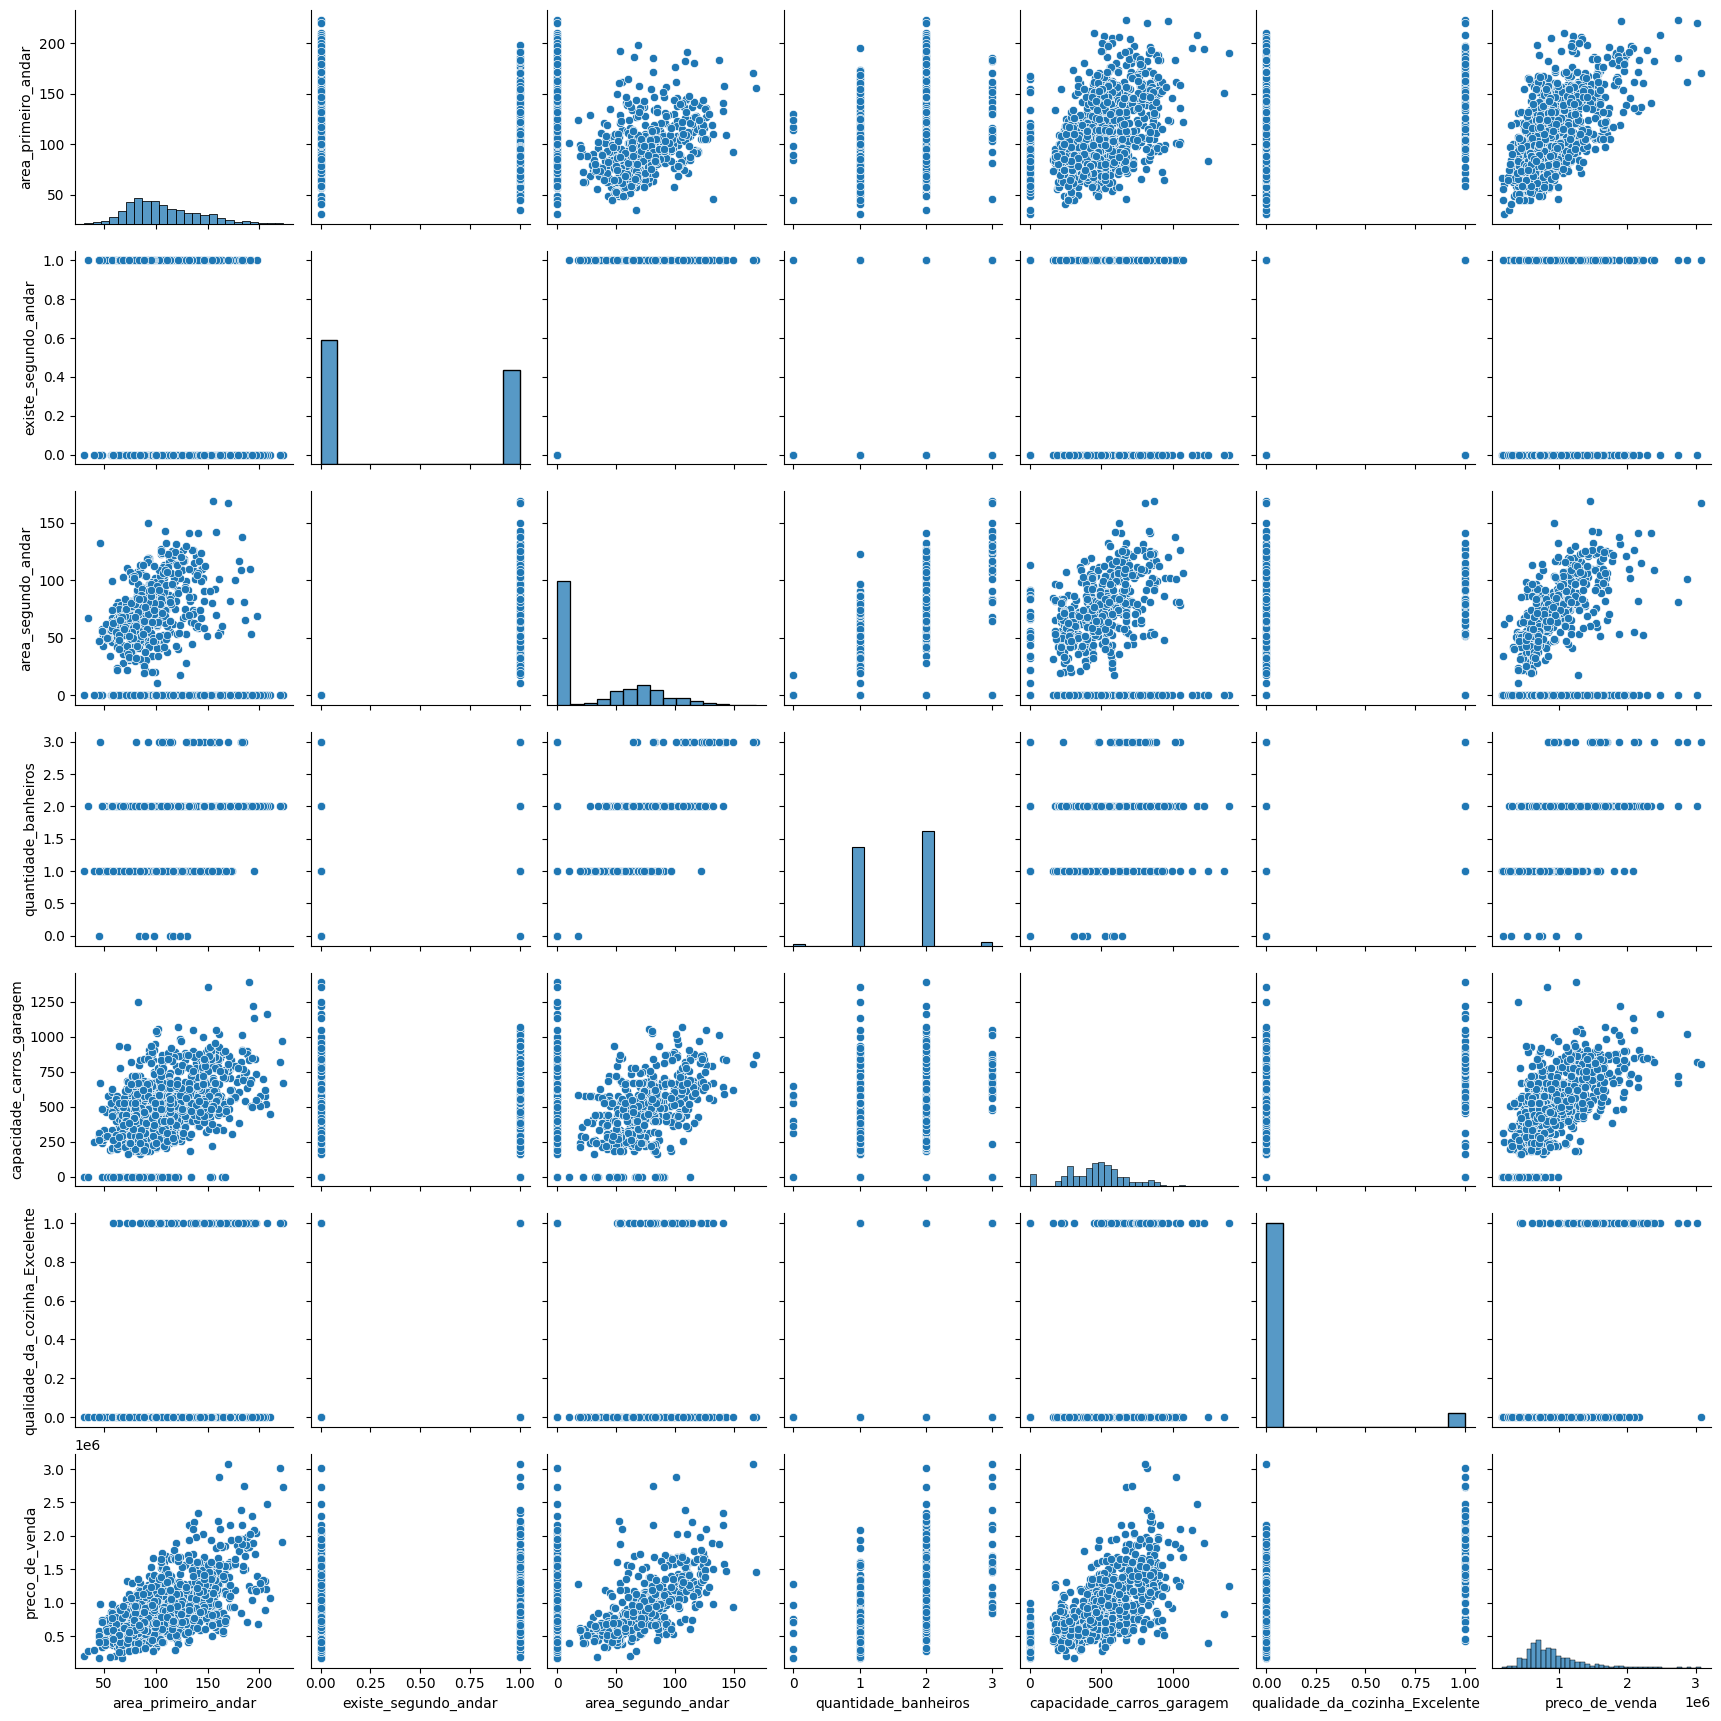

In [30]:
#entender quais outras caracteristicas podem explicar o preço do imovel
sns.pairplot(dados)

In [31]:
dados.columns

Index(['area_primeiro_andar', 'existe_segundo_andar', 'area_segundo_andar',
       'quantidade_banheiros', 'capacidade_carros_garagem',
       'qualidade_da_cozinha_Excelente', 'preco_de_venda'],
      dtype='object')

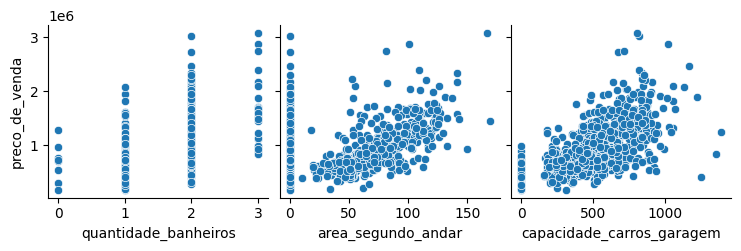

In [35]:
sns.pairplot(dados, y_vars='preco_de_venda', x_vars=['quantidade_banheiros', 'area_segundo_andar', 'capacidade_carros_garagem'])
#Aqui podemos entender o que tem de relação com o valor da casa, por exemplo, quanto mais banheiros, mais alto seu valor

In [34]:
import statsmodels.api as sm

In [38]:
x_train = sm.add_constant(x_train)
#O sm.add_constant adiciona uma nova coluna onde todas as linhas se iniciam em 1, isto é o Intercepto, é o ponto de partida do modelo
x_train.head()
#o sm.add_constant adiciona essa coluna de "1"s ao X_train, permitindo que o modelo sm.OLS estime um intercepto para o preço de venda da casa. Isso significa que o
#modelo pode prever um preço base para a casa, mesmo que as áreas, número de banheiros e outras características sejam zero, o que é mais realista

,const,area_primeiro_andar,existe_segundo_andar,area_segundo_andar,quantidade_banheiros,capacidade_carros_garagem,qualidade_da_cozinha_Excelente
1303,1.0,65.7732,0,0.0000,1,0,0
326,1.0,55.3684,1,55.3684,1,189,0
386,1.0,74.6916,1,107.4853,2,560,0
615,1.0,103.6764,0,0.0000,1,440,0
236,1.0,94.2006,1,67.8170,2,457,0


In [40]:
x_train.columns

Index(['const', 'area_primeiro_andar', 'existe_segundo_andar',
       'area_segundo_andar', 'quantidade_banheiros',
       'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente'],
      dtype='object')

In [48]:
#Modelo com a maioria das variaveis
modelo_1 = sm.OLS(y_train, x_train[['const', 'area_primeiro_andar', 'existe_segundo_andar',
                                    'area_segundo_andar', 'quantidade_banheiros',
                                    'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente']]).fit()

In [51]:
#Modelo com a maiotia das variaveis mas sem o 'area_segundo_andar'
modelo_2 = sm.OLS(y_train,
                  x_train[['const', 'area_primeiro_andar',
                           'existe_segundo_andar','quantidade_banheiros',
                           'capacidade_carros_garagem', 'qualidade_da_cozinha_Excelente']]).fit()

In [50]:
#Modelo com a maiotia das variaveis mas sem o 'area_segundo_andar' e sem a 'capacidade_carros_garagem'
modelo_3 = sm.OLS(y_train,
                  x_train[['const', 'area_primeiro_andar', 'existe_segundo_andar',
                           'quantidade_banheiros','qualidade_da_cozinha_Excelente']]).fit()

#Entendimento
* Criamos os modelos com as diferentes fatures para entender melhor qual dos tres modelos tem mais relação com o valor de venda da casa
* Ou seja, iremos comparar qual dos modelos tem o maior R² de previsão
* Com isso também conseguimos identificar qual variavel tem a maior relevancia no valor da casa
* O objetivo final é encontrar um modelo que seja preciso, mas também interpretabilidade e que utilize as variáveis mais importantes para explicar o preço de venda.

In [53]:
print(modelo_1.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     477.4
Date:                Mon, 07 Sep 2026   Prob (F-statistic):          2.79e-289
Time:                        18:25:20   Log-Likelihood:                -13640.
No. Observations:                1006   AIC:                         2.729e+04
Df Residuals:                     999   BIC:                         2.733e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [54]:
print(modelo_2.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.708
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     485.3
Date:                Mon, 07 Sep 2026   Prob (F-statistic):          1.93e-264
Time:                        18:25:49   Log-Likelihood:                -13701.
No. Observations:                1006   AIC:                         2.741e+04
Df Residuals:                    1000   BIC:                         2.744e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [55]:
print(modelo_3.summary())

                            OLS Regression Results                            
Dep. Variable:         preco_de_venda   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     467.1
Date:                Mon, 07 Sep 2026   Prob (F-statistic):          4.15e-227
Time:                        18:25:56   Log-Likelihood:                -13790.
No. Observations:                1006   AIC:                         2.759e+04
Df Residuals:                    1001   BIC:                         2.762e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

#Escolha do Modelo 3
Este modelo foi escolhido mesmo tendo maior R² por não apresnetar multicolinearidade e por não ter mudança nos coeficientes que indicam um efeito de confundimento.
* Multicolinearidade: A multicolinearidade ocorre quando duas ou mais variáveis explicativas em um modelo de regressão estão altamente correlacionadas entre si. Isso pode dificultar a interpretação dos coeficientes individuais das variáveis, pois o modelo não consegue distinguir claramente o impacto de cada uma. No rodapé dos Modelos 1 e 2 pode ser encontrado está Multicolinearidade
* Efeito de Confundimento: É apontado que, nos Modelos 1 e 2, a variável `existe_segundo_andar` mudava o sinal do seu coeficiente (de negativo para positivo) dependendo da presença da variável `area_segundo_andar`. Isso sugere que as duas variáveis estavam "confundindo" o efeito uma da outra sobre o preço da casa, pois ambas se referem ao segundo andar. No Modelo 3, o coeficiente de `existe_segundo_andar` permaneceu positivo, o que indica uma relação mais consistente e menos confusa.

In [65]:
print("R²")
print("Modelo 0: ", modelo_0.rsquared) #Lembrando que o modelo 0 possui somente duas comparaçõe, o valor da casa e area (line 20)
print("Modelo 1: ", modelo_1.rsquared)
print("Modelo 2: ", modelo_2.rsquared)
print("Modelo 3: ", modelo_3.rsquared)

R²
Modelo 0:  0.37728010994297867
Modelo 1:  0.7414024156090393
Modelo 2:  0.7081440416220739
Modelo 3:  0.6511289354898803


In [67]:
print(len(modelo_0.params))
print(len(modelo_1.params))
print(len(modelo_2.params))
print(len(modelo_3.params))

2
7
6
5


In [68]:
modelo_3.params

,0
const,-129979.678094
area_primeiro_andar,6119.653184
existe_segundo_andar,221306.959705
quantidade_banheiros,149036.289458
qualidade_da_cozinha_Excelente,444391.228573
